#**Business Case: Walmart Black Friday**

**Using Confidence Interval and CLT**

**Gender-based analysis to understand whether purchase behavior differs between male and female customers during Black Friday sales.**

**We will use:**
1. Python
2. Pandas
3. Matplotlib
4. Seaborn
5. Central Limit Theorem
6. Confidence Interval (CI)

#**Task 1: Importing Libraries**

In [1]:
#basic libraries
import pandas as pd
import numpy as np

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

#importing statistical calculations
from scipy import stats

#**Task 2: Importing Dataset**

In [2]:
!pip install gdown

In [3]:
!gdown --id 10RoaEgze8ChDNSP_ujg1O_8pTfXyYyNi

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=10RoaEgze8ChDNSP_ujg1O_8pTfXyYyNi
To: /content/walmart_data.csv
100% 10.7M/10.7M [00:00<00:00, 44.9MB/s]


In [4]:
df_walmart=pd.read_csv('walmart_data.csv')
walmart=df_walmart.copy()

#**Understanding the dataset**

In [5]:
walmart.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10.0,A,2,0.0,3.0,8370.0
1,1000001,P00248942,F,0-17,10.0,A,2,0.0,1.0,15200.0
2,1000001,P00087842,F,0-17,10.0,A,2,0.0,12.0,1422.0
3,1000001,P00085442,F,0-17,10.0,A,2,0.0,12.0,1057.0
4,1000002,P00285442,M,55+,16.0,C,4+,0.0,8.0,7969.0


In [6]:
#checking the number of rows and columns
walmart.shape

(250446, 10)

In [7]:
#checking all column names
walmart.columns

Index(['User_ID', 'Product_ID', 'Gender', 'Age', 'Occupation', 'City_Category',
       'Stay_In_Current_City_Years', 'Marital_Status', 'Product_Category',
       'Purchase'],
      dtype='object')

In [8]:
#checking of data types and null-values
walmart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250446 entries, 0 to 250445
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     250446 non-null  int64  
 1   Product_ID                  250446 non-null  object 
 2   Gender                      250445 non-null  object 
 3   Age                         250445 non-null  object 
 4   Occupation                  250445 non-null  float64
 5   City_Category               250445 non-null  object 
 6   Stay_In_Current_City_Years  250445 non-null  object 
 7   Marital_Status              250445 non-null  float64
 8   Product_Category            250445 non-null  float64
 9   Purchase                    250445 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 19.1+ MB


In [9]:
walmart.isnull().sum()
#out of 10 columns, 8 columns have 1 null value each.

,0
User_ID,0
Product_ID,0
Gender,1
Age,1
Occupation,1
City_Category,1
Stay_In_Current_City_Years,1
Marital_Status,1
Product_Category,1
Purchase,1


In [10]:
#statistical summary
#this summary will help in understanding its distribution and spread of data
walmart.describe()

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
count,2.504460e+05,250445.000000,250445.000000,250445.000000,250445.000000
mean,1.002913e+06,8.073805,0.410489,5.294588,9313.668754
std,1.735069e+03,6.529494,0.491924,3.744684,4967.982450
min,1.000001e+06,0.000000,0.000000,1.000000,185.000000
25%,1.001395e+06,2.000000,0.000000,1.000000,5862.000000
50%,1.002869e+06,7.000000,0.000000,5.000000,8058.000000
75%,1.004384e+06,14.000000,1.000000,8.000000,12055.000000
max,1.006040e+06,20.000000,1.000000,18.000000,23961.000000


#**Detecting Outliers**

**using boxplot, “describe” method by checking the difference between mean and median**

In [11]:
walmart.select_dtypes(['int64','float64'])

,User_ID,Occupation,Marital_Status,Product_Category,Purchase
0,1000001,10.0,0.0,3.0,8370.0
1,1000001,10.0,0.0,1.0,15200.0
2,1000001,10.0,0.0,12.0,1422.0
3,1000001,10.0,0.0,12.0,1057.0
4,1000002,16.0,0.0,8.0,7969.0
...,...,...,...,...,...
250441,1002627,1.0,1.0,8.0,5857.0
250442,1002627,1.0,1.0,1.0,11571.0
250443,1002627,1.0,1.0,6.0,16489.0
250444,1002627,1.0,1.0,1.0,15164.0


In [12]:
walmart.groupby('User_ID')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
User_ID,,,,,,,,
1000001,20.0,9680.650000,5074.420737,1057.0,7606.75,9421.0,13631.50,19219.0
1000002,27.0,10663.703704,4174.274417,5260.0,7836.50,10074.0,12061.50,20434.0
1000003,9.0,14052.111111,3488.828437,7193.0,12103.00,15292.0,15430.00,19302.0
1000004,7.0,15609.857143,5483.794472,3849.0,15769.00,15854.0,19167.50,19693.0
1000005,43.0,8003.162791,4113.357578,1938.0,5210.00,6078.0,10764.00,21021.0
...,...,...,...,...,...,...,...,...
1006036,226.0,7754.548673,4059.837206,370.0,5336.00,7112.0,8896.75,20815.0
1006037,53.0,10268.792453,4751.690640,3502.0,7767.00,8747.0,12598.00,23714.0
1006038,3.0,6072.666667,754.563008,5382.0,5670.00,5958.0,6418.00,6878.0


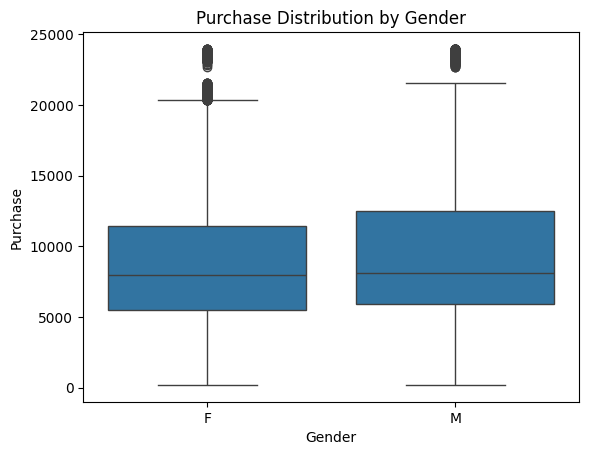

In [13]:
sns.boxplot(x='Gender', y='Purchase', data=walmart)
plt.title('Purchase Distribution by Gender')
plt.show()

In [14]:
#average transaction amount for male and female customers.
gender_stats=walmart.groupby('Gender')['Purchase'].agg([np.mean])
print(gender_stats)


              mean
Gender            
F       8796.63869
M       9482.87655


/tmp/ipykernel_1970/4042098586.py:2: FutureWarning: The provided callable <function mean at 0x7d52c367d940> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  gender_stats=walmart.groupby('Gender')['Purchase'].agg([np.mean])


**I grouped the dataset by gender and calculated the mean purchase amount to analyze spending behavior. The results showed that male customers have a higher average transaction value (₹9482.88) than female customers (₹8796.64), indicating that male customers spend more per transaction on Walmart purchases.”**

> **Business Interpretation**

- Male customers purchased more higher-priced products
- Male customers may buy in larger quantities

In [15]:
#calculating the Confidence Interval for female customers(CI)

#extracting female purchse data

female_purchase=walmart[walmart['Gender']=='F']['Purchase']

#calcualting mean, samplesize and standard deviation
fem_mean=female_purchase.mean()
female_stdev=female_purchase.std()
sample_size=female_purchase.count()

print(f"female_mean:{fem_mean}, female_Standard_deviation:{female_stdev},sample_size:{sample_size}")

female_mean:8796.638689618318, female_Standard_deviation:4699.36389630909,sample_size:61753


In [16]:
#for 95% confidence interval
z=1.96
lower_limit=fem_mean - z*(female_stdev/np.sqrt(sample_size))
upper_limit=fem_mean + z*(female_stdev/np.sqrt(sample_size))

print(f"lower_limit is: {lower_limit}")
print(f"upper_limit is: {upper_limit}")

lower_limit is: 8759.573509322281
upper_limit is: 8833.703869914354


**Infrence: We are 95% confident that the average spending of all 50 million female customers lies between 8759.57 and 8833.70.**

In [17]:
#calculating the Confidence Interval for male customers(CI)

male_purchase=walmart[walmart['Gender']=='M']['Purchase']

#calcualting mean, standard deviation and sample size

male_mean=male_purchase.mean()
male_stdev=male_purchase.std()
sample_size=male_purchase.count()

print(f"mean purchase of male: {male_mean}")
print(f"standard deviation: {male_stdev}")
print(f"sample size: {sample_size}")

mean purchase of male: 9482.87655014521
standard deviation: 5041.300890400068
sample size: 188692


In [18]:
#calcualting confidence intervale at 90%
z=1.96
lower_limit=male_mean - z * (male_stdev/np.sqrt(sample_size))
upper_limit=male_mean + z * (male_stdev/np.sqrt(sample_size))

print(f"lower limit of purchase is: {lower_limit}")
print(f"upper limit of purchase is: {upper_limit}")

lower limit of purchase is: 9460.1296643793
upper limit of purchase is: 9505.623435911122


**Conclusion: Using the sample data we can conclude that the male confidence interval is higher than the female interval, male customers are expected to spend more on average.**

**The reason we are doing this because, we cannot analyze all 50 million customers directly, we use sample statistics to estimate the population mean within a confidence range.**

> **Distribution plot of 'Purchase_Amount'**

<Axes: xlabel='Purchase', ylabel='Count'>

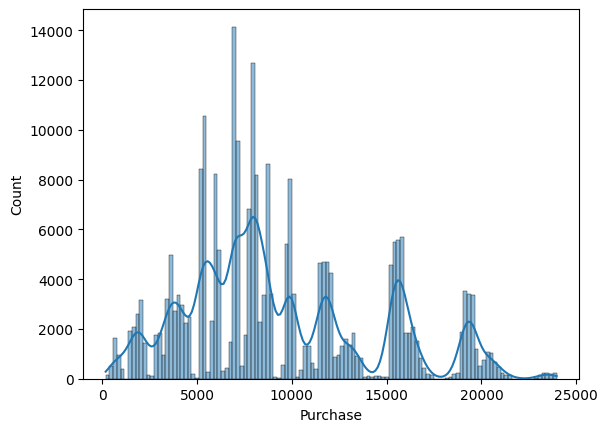

In [19]:
#to understand spending pattern & skewnes
sns.histplot(x='Purchase', kde=True, data=walmart)

**Infrence:**

> - Visualizing the above graph we can say that it is rightly-skewed and most of the customers are spending.
>- greater amount of customers are spending lower amount.
>- few customers are spending on higher amount.


**Mean Distribution using Sampling (CLT Visualization)**

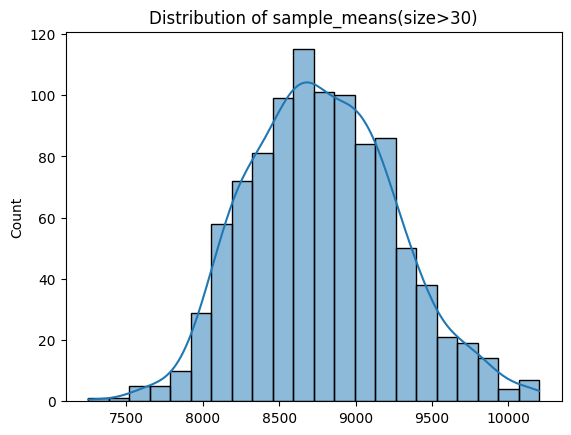

In [29]:
'''
In order to prove central limit theorem which is 'CLT works for any sample size'
difference can be visualize for 'sample_size>30'
'''
sample_means=[]
for i in range(1000):
  sample_data=walmart[walmart['Gender']=='F'].sample(100)
  sample_means.append(sample_data['Purchase'].mean())

#visualizaiton of 'central limit theorem'
sns.histplot(sample_means, kde=True)
plt.title("Distribution of sample_means(size>30)")
plt.show()

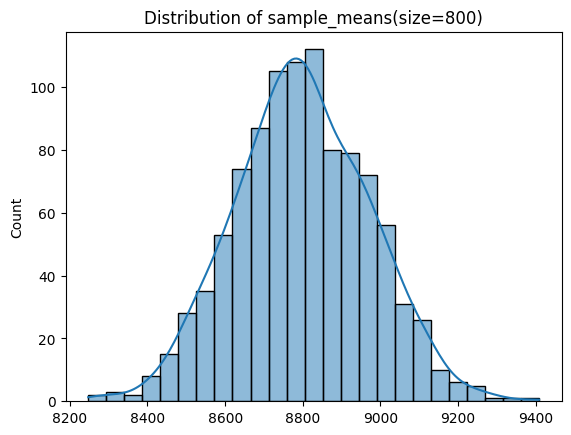

In [33]:
#for 'sample_size=800 (highly big data)'

sample_means=[]
for i in range(1000):
  sample_data=walmart[walmart['Gender']=='F'].sample(800)
  sample_means.append(sample_data['Purchase'].mean())

#visualizaiton of 'central limit theorem'
sns.histplot(sample_means, kde=True)
plt.title("Distribution of sample_means(size=800)")
plt.show()

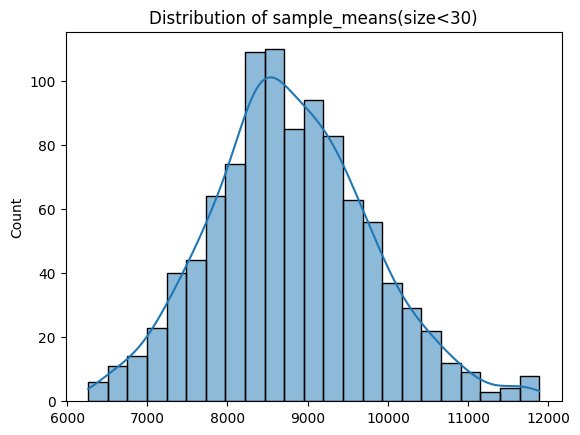

In [32]:
#'sample_size<30'
sample_means=[]
for i in range(1000):
  sample_data=walmart[walmart['Gender']=='F'].sample(20)
  sample_means.append(sample_data['Purchase'].mean())

#visualizaiton of 'central limit theorem'
sns.histplot(sample_means, kde=True)
plt.title("Distribution of sample_means(size<30)")
plt.show()

> * The central limit theorem applies to any sample size, but the approximation of sampling_distribution of the sample means to a normal distribution becomes better (when the sample_size>30).

> * The central limit theorem applies to any sample size, but the approximation of sampling_distribution of the sample means to a normal distribution becomes better (when the sample_size>30).

> * If the population is highly skewed, sample_distribution can be scattered.
 >* if the sample_size is high (sample_size=800) the sample_means become close to normal

#**Recommendation for 'Walmart'**

'''
> Male customers hsows high_average purchase amount.
> * Promote premium products to male customers wil be good.
> * Electronics, gadgets, gaming, and lifestyle products can be bundled.
> * Running campaigns
'''

> Increasing female customer spending
> * Customized and personalized discounts.
> * comobo offers specially on (womans day, mothers day, and other festivals)
> * Fashion and home products can be bundled.

> Handling outliers
> * Boxplot and mean-median comparison indicated outliers.
> * In order to detetct 'frauds' analyze of high-value transaction is recommended.
> * Understanding premium customer's purchase behavior

# **Conclusion:**
> The analysis indicates that male customers contribute higher average transaction value(ATV), while female customers represent an opportunity for targeted growth strategies. Statistical techniques like CLT and confidence intervals provide reliable estimated data for customer spending behavior that can help Walmart making data-driven decisions related to marketing, inventory, customer segmentation, and revenue optimization funnels.